In [133]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [134]:
file_path = "X data.csv" 
df = pd.read_csv(file_path)


In [135]:
df.columns = ['tweet', 'sentiment'] 

In [136]:
# Text Cleaning using NLTK

stop_words = set(stopwords.words("english"))

def preprocess(text):
    tokens = word_tokenize(str(text).lower())
    tokens = [word for word in tokens if word.isalpha()]
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

df["clean_tweet"] = df["tweet"].apply(preprocess)

df.head()

,tweet,sentiment,clean_tweet
0,when modi promised “minimum government maximum...,-1,modi promised minimum government maximum gover...
1,talk all the nonsense and continue all the dra...,0,talk nonsense continue drama vote modi
2,what did just say vote for modi welcome bjp t...,1,say vote modi welcome bjp told rahul main camp...
3,asking his supporters prefix chowkidar their n...,1,asking supporters prefix chowkidar names modi ...
4,answer who among these the most powerful world...,1,answer among powerful world leader today trump...


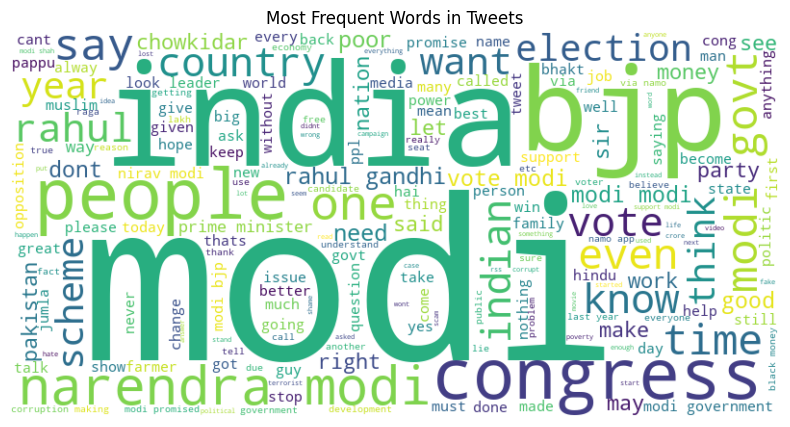

In [137]:
# Generate and display a WordCloud for cleaned tweets
all_words = " ".join(df["clean_tweet"].dropna())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in Tweets")
plt.savefig("sentiment_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [138]:
# TF-IDF Feature Extraction

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X = tfidf.fit_transform(df["clean_tweet"])

y = df["sentiment"]

In [139]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [140]:
# Logistic Regression Model

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [141]:
# Prediction

y_pred = model.predict(X_test)

In [142]:
# Evaluation

print("Accuracy :", accuracy_score(y_test, y_pred))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.8322271386430679

Classification Report

              precision    recall  f1-score   support

          -1       0.85      0.68      0.75      1265
           0       0.80      0.92      0.86      1889
           1       0.86      0.84      0.85      2270

    accuracy                           0.83      5424
   macro avg       0.83      0.82      0.82      5424
weighted avg       0.83      0.83      0.83      5424



In [143]:
def predict_sentiment(text):
    cleaned = preprocess(text)
    vectorized = tfidf.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    return prediction

# Test with custom examples
print(predict_sentiment("I absolutely love using this app, it works so smoothly!"))
print(predict_sentiment("This service is terrible and keeps crashing."))

1
0


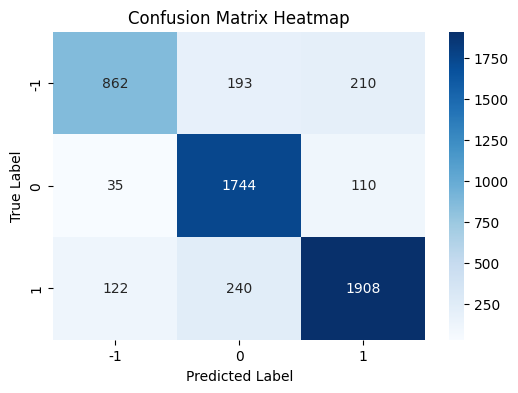

In [144]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, 
            yticklabels=model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [145]:
import joblib

# Save both artifacts to disk
joblib.dump(model, 'sentiment_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [146]:
# 1. Add model predictions to the DataFrame
df['predicted_sentiment'] = model.predict(X)

# 2. Export the final dataset to CSV
df.to_csv("final_sentiment_analysis_results.csv", index=False)